# Autocorrelation analysis and lag selection

Building an autoregressive forecaster requires deciding *which past values of the series should be used as predictors*. The autocorrelation function (ACF) and the partial autocorrelation function (PACF) are the standard diagnostic tools for that question: they measure how the present value of a series is linked to its own past, and they are the most reliable starting point for choosing the `lags` argument of any skforecast forecaster.

This guide focuses on **understanding the dynamics of the series** — what ACF and PACF actually measure, how to read them, and how to translate those readings into a sensible set of candidate lags. Once a candidate set is identified, the [Hyperparameter tuning and lags selection](../user_guides/hyperparameter-tuning-and-lags-selection.html) guide shows how to refine the choice via cross-validation, and the [Feature selection](../user_guides/feature-selection.html) guide explains how to prune the redundant ones.

<div class="admonition note" name="html-admonition" style="background: rgba(0,184,212,.1); padding-top: 0px; padding-bottom: 6px; border-radius: 8px; border-left: 8px solid #00b8d4; border-color: #00b8d4; padding-left: 10px; padding-right: 10px;">

<p class="title">
    <i style="font-size: 18px; color:#00b8d4;"></i>
    <b style="color: #00b8d4;">&#9999;&#65039; Note</b>
</p>

The `acf` and `pacf` functions exposed in `skforecast.stats` mirror the public API of `statsmodels.tsa.stattools.acf` and `statsmodels.tsa.stattools.pacf`, but they have been reimplemented from scratch (FFT for the ACF, Levinson&ndash;Durbin recursion for the PACF) to <b>maximise speed on long time series</b>. Only the most common configuration options are exposed.

If you are looking for the wide range of statistical flavours offered by statsmodels &mdash; alternative estimators (<code>'ywunbiased'</code>, <code>'ols'</code>, <code>'ld'</code>, <code>'burg'</code>), Ljung&ndash;Box statistics, multiple confidence-interval estimators, and so on &mdash; we recommend exploring the methods implemented in <a href="https://www.statsmodels.org/stable/tsa.html">statsmodels.tsa</a> directly.

For plotting we still rely on the statsmodels helpers, using the fastest configuration:<br>
<code>plot_acf(..., alpha=0.05, fft=True)</code> and <code>plot_pacf(..., alpha=0.05, method='burg')</code>.

</div>

## Libraries

In [7]:
# Data manipulation
# ==============================================================================
import numpy as np
import pandas as pd

# Plots
# ==============================================================================
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from skforecast.plot import set_dark_theme
set_dark_theme()

# Skforecast
# ==============================================================================
from skforecast.stats import acf, pacf, calculate_lag_autocorrelation
from skforecast.datasets import fetch_dataset
from skforecast.recursive import ForecasterRecursive

## Autocorrelation function (ACF)

The ACF at lag *k* measures the **total linear correlation** between $y_t$ and $y_{t-k}$, including any indirect dependence routed through the intermediate lags $y_{t-1}, \dots, y_{t-k+1}$. As a consequence, a single strong dependence on the immediate past propagates and produces non-zero autocorrelation at many subsequent lags.

A common rule of thumb when identifying a process from its ACF:

- **ACF cuts off sharply after lag *q*** &rarr; suggests an MA(q) component.
- **ACF decays slowly** (geometric or oscillating) &rarr; suggests an AR or mixed process.

Below, an AR(1) series with $\phi = 0.7$ is simulated and analysed. The expected pattern is a geometric decay of the ACF.

In [8]:
# Simulate an AR(1) process: y_t = 0.7 * y_{t-1} + eps_t
# ==============================================================================
rng = np.random.default_rng(42)
n = 500
phi = 0.7
y_ar1 = np.zeros(n)
for t in range(1, n):
    y_ar1[t] = phi * y_ar1[t - 1] + rng.standard_normal()

# ACF with 95% Bartlett confidence intervals
acf_vals, confint = acf(y_ar1, nlags=20, alpha=0.05)
print('ACF, lags 0-5:', acf_vals[:6].round(3))

ACF, lags 0-5: [1.    0.712 0.456 0.259 0.131 0.052]


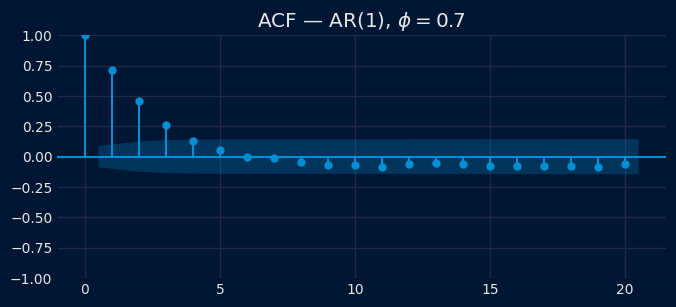

In [9]:
# Plot the ACF (statsmodels, fastest configuration)
# ==============================================================================
fig, ax = plt.subplots(figsize=(7, 3))
plot_acf(y_ar1, lags=20, alpha=0.05, fft=True, ax=ax)
ax.set_title('ACF — AR(1), $\\phi = 0.7$')
plt.show()

## Partial autocorrelation function (PACF)

The PACF at lag *k* measures the linear correlation between $y_t$ and $y_{t-k}$ **after removing the linear effect of all intermediate lags** $y_{t-1}, \dots, y_{t-k+1}$. It isolates the *direct* contribution of lag *k*, which is exactly what is needed to choose the order of an autoregressive model.

Reading rule:

- **PACF cuts off after lag *p*** &rarr; suggests an AR(p) component (lags 1 to *p* are the relevant ones).
- **PACF decays slowly** &rarr; suggests an MA or mixed process.

Below, an AR(2) series is simulated. The expected pattern is two significant PACF coefficients at lags 1 and 2, and everything else inside the white-noise band.

In [10]:
# Simulate an AR(2) process: y_t = 0.6 * y_{t-1} - 0.3 * y_{t-2} + eps_t
# ==============================================================================
phi1, phi2 = 0.6, -0.3
y_ar2 = np.zeros(n)
for t in range(2, n):
    y_ar2[t] = phi1 * y_ar2[t - 1] + phi2 * y_ar2[t - 2] + rng.standard_normal()

# PACF with 95% white-noise confidence intervals
pacf_vals, confint = pacf(y_ar2, nlags=20, alpha=0.05)
print('PACF, lags 0-5:', pacf_vals[:6].round(3))

PACF, lags 0-5: [ 1.     0.482 -0.348  0.084 -0.031 -0.008]


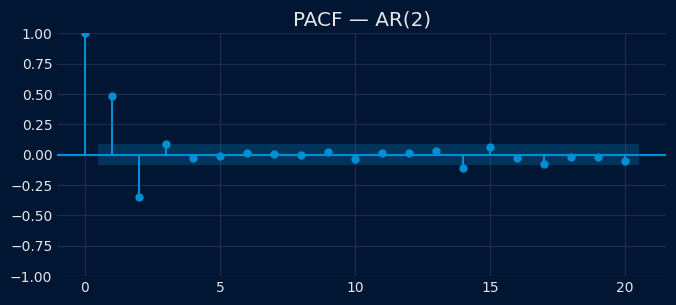

In [11]:
# Plot the PACF (statsmodels, fastest configuration)
# ==============================================================================
fig, ax = plt.subplots(figsize=(7, 3))
plot_pacf(y_ar2, lags=20, alpha=0.05, method='burg', ax=ax)
ax.set_title('PACF — AR(2)')
plt.show()

## Detecting trend and seasonality on a real series

Real series rarely look like a clean AR or MA process: trend and seasonality typically dominate the ACF and PACF, and reading them is one of the quickest ways to detect those components. As an example, we use the `h2o` dataset (monthly Australian expenditure on corticosteroid drugs, 1991&ndash;2008) included in `skforecast.datasets`.

In [12]:
# Load monthly time series
# ==============================================================================
data = fetch_dataset(name='h2o', verbose=False)
y = data['x'].rename('y')
y.head()

fecha
1991-07-01    0.429795
1991-08-01    0.400906
1991-09-01    0.432159
1991-10-01    0.492543
1991-11-01    0.502369
Freq: MS, Name: y, dtype: float64

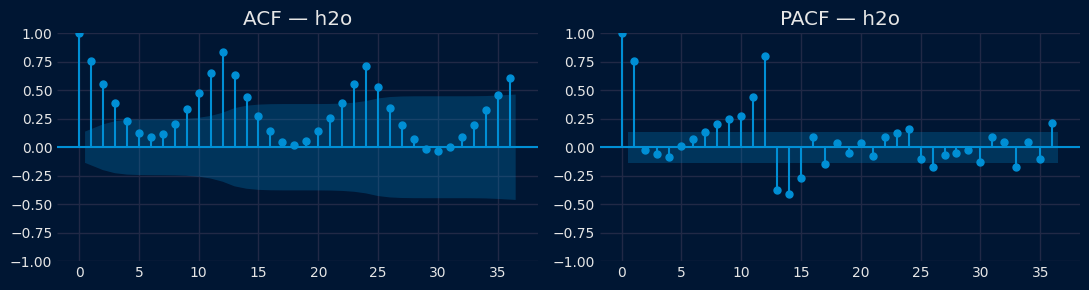

In [13]:
# Joint ACF / PACF view
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(11, 3))
plot_acf(y, lags=36, alpha=0.05, fft=True, ax=axes[0])
plot_pacf(y, lags=36, alpha=0.05, method='burg', ax=axes[1])
axes[0].set_title('ACF — h2o')
axes[1].set_title('PACF — h2o')
plt.tight_layout()
plt.show()

Two patterns are visible:

- The **ACF decays slowly and shows clear peaks at lags 12, 24 and 36**, the unmistakable signature of an annual seasonal cycle on monthly data.
- The **PACF has a strong spike at lag 1** and additional smaller spikes around lag 12, suggesting that the most informative *direct* dependencies are the previous month and the same month one year ago.

This already provides a sensible starting point: lag 1 for short-term inertia and lag 12 (and possibly 13) to capture the annual seasonality.

## Ranking lags with `calculate_lag_autocorrelation`

When a tabular view is more convenient — for example, to feed an automatic lag selection routine — `calculate_lag_autocorrelation` returns a DataFrame with ACF and PACF values for all lags, sorted by absolute partial autocorrelation. This makes it easy to keep the *N* lags that contribute most to the conditional variance.

In [14]:
# Top lags ranked by |PACF|
# ==============================================================================
lag_table = calculate_lag_autocorrelation(
    data=y,
    n_lags=24,
    sort_by='partial_autocorrelation_abs'
)
lag_table.head(10)

,lag,partial_autocorrelation_abs,partial_autocorrelation,autocorrelation_abs,autocorrelation
0,1,0.754819,0.754819,0.754819,0.754819
1,13,0.581951,-0.581951,0.630189,0.630189
2,12,0.564231,0.564231,0.838637,0.838637
3,11,0.357985,0.357985,0.650629,0.650629
4,10,0.229213,0.229213,0.479473,0.479473
5,14,0.221144,-0.221144,0.437928,0.437928
6,9,0.214591,0.214591,0.334505,0.334505
7,8,0.168774,0.168774,0.202611,0.202611
8,7,0.126981,0.126981,0.115865,0.115865
9,16,0.111945,0.111945,0.139812,0.139812


In [15]:
# Keep lags whose |PACF| exceeds the asymptotic 95% white-noise band (1.96 / sqrt(n))
# ==============================================================================
threshold = 1.96 / np.sqrt(len(y))
selected_lags = (
    lag_table
    .loc[lag_table['partial_autocorrelation_abs'] > threshold, 'lag']
    .astype(int)
    .sort_values()
    .tolist()
)
print(f'Selected lags: {selected_lags}')

Selected lags: [1, 8, 9, 10, 11, 12, 13, 14]


## Using the selected lags in a Forecaster

The selected lags can be passed directly to any skforecast forecaster. The example below trains a `ForecasterRecursive` with a gradient boosting estimator and the lags identified from the PACF.

In [16]:
# Build a forecaster with the selected lags
# ==============================================================================
from sklearn.ensemble import HistGradientBoostingRegressor

forecaster = ForecasterRecursive(
                 estimator = HistGradientBoostingRegressor(random_state=963),
                 lags      = selected_lags
             )
forecaster.fit(y=y)
forecaster.predict(steps=12).round(2)

2008-07-01    0.90
2008-08-01    1.05
2008-09-01    1.13
2008-10-01    1.18
2008-11-01    1.14
2008-12-01    1.18
2009-01-01    1.19
2009-02-01    0.82
2009-03-01    0.70
2009-04-01    0.81
2009-05-01    0.82
2009-06-01    0.82
Freq: MS, Name: pred, dtype: float64

<div class="admonition note" name="html-admonition" style="background: rgba(0,191,191,.1); padding-top: 0px; padding-bottom: 6px; border-radius: 8px; border-left: 8px solid #00bfa5; border-color: #00bfa5; padding-left: 10px; padding-right: 10px;">

<p class="title">
    <i style="font-size: 18px; color:#00bfa5;"></i>
    <b style="color: #00bfa5;">&#128161; Tip</b>
</p>

The lags identified from ACF/PACF analysis are an informed <i>starting point</i>, not a final answer. Once a candidate set is chosen, the <a href="../user_guides/hyperparameter-tuning-and-lags-selection.html">Hyperparameter tuning and lags selection</a> guide shows how to refine it via cross-validation, and the <a href="../user_guides/feature-selection.html">Feature selection</a> guide explains how to prune redundant predictors.

</div>